In [1]:
import importlib
import sys
sys.path.insert(0, '/glade/work/rneale/git/python-scripts/SONDE')
import raobs_utils as mypy
importlib.reload(mypy)

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# ---- Station(s) to process ----
station_names = ['Denver']
# station_names = ['EasterIsland','SanCristobal','Hilo','Tarawa','GrandCayman']

crun_name = None
# ---- Model run (comment out both lines to use RAOB obs only) ----
crun_name = 'b.e11.B20TRC5CNBDRD.f09_g16.001'
crun_type = 'large_ens'   # 'large_ens' or 'cam6_revert'
# crun_name = 'f.e20.FHIST.f09_f09.cesm2_1.001'
# crun_type = 'cam6_revert'

# ---- Variables ----
vplot1d = 'PRECT'    # 1D variable (PS, PRECT, etc.)
vplot2d = 'U'     # 2D variable (U, V, T, Q, RELHUM, DTCOND)

# ---- Year range ----
year_first = 1990
year_last  = 2015

# ---- Level type ----
lev_type = 'M'   # M=mandatory, T=significant temp, W=significant wind

# ---- Directories ----ƒcrun
dir_rdata = '/glade/work/rneale/data/raobs/'
dir_fig   = '/glade/u/home/rneale/python/python-figs/raobs/'
os.makedirs(dir_fig, exist_ok=True)

# ---- Plot flags ----
sdata_base = {
    'year_first'  : year_first,
    'year_last'   : year_last,
    'lev_type'    : lev_type,
    'drunave'     : 60,      # running-mean window (days)
    'lp1d'        : True,
    'lp1d_0012Z'  : True,    # plot 00Z and 12Z separately
    'lp1d_av_std' : True,    # plot mean +/- 1 std
    'lp2d'        : True,
    'lp2d_mean'   : True,    # plot mean annual cycle
    'lp2d_0012Z'  : False,   # 3-panel 00Z / 12Z / difference
    'lp2d_nomean' : False,   # remove mean annual cycle
    'lp2d_std'    : False,   # overplot std dev
}


  Station: Denver
  Station 'Denver' file found: /glade/work/rneale/data/raobs/raob_soundings_Denver.cdf
  RAOB: decoding synTime coordinate...

*****************************************************************
  INFO FROM RAOB FILE
*****************************************************************
  Station : Denver  (WMO id: 72469)
  Lat: 39.77  Lon: -104.88  Elev: 1611 m
  Time range: 12Z 01 Jan 1985 to 12Z 28 Oct 2015
  Requested year range: 1990 – 2015
  Output levels: [1000.  925.  850.  700.  500.  400.  300.  250.  200.  150.  100.   70.
   50.   30.   20.   10.] mb


  CAM simulation: b.e11.B20TRC5CNBDRD.f09_g16.001
  Processed CAM file exists for PRECT: /glade/work/rneale/large_ens/PRECT/b.e11.B20TRC5CNBDRD.f09_g16.001.cam.h2.PRECT.Denver.nc

*****************************************************************
  CAM: reading PRECT
*****************************************************************
  Station location: 39.77 N, -104.88 E
  Reading from pre-processed file...
  Time r

/glade/work/rneale/git/python-scripts/SONDE/raobs_utils.py:752: UserWarning: Requested year range 1990-2015 is outside available 1990-2006 in CAM file.
  warnings.warn(


  Nearest GPCP grid point: 39.50 N, 255.50 E


/glade/work/rneale/git/python-scripts/SONDE/raobs_utils.py:832: FutureWarning: In a future version, xarray will not decode the variable 'datesec' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(fpath)


  Nearest TRMM grid point: 39.88 N, -104.88 E


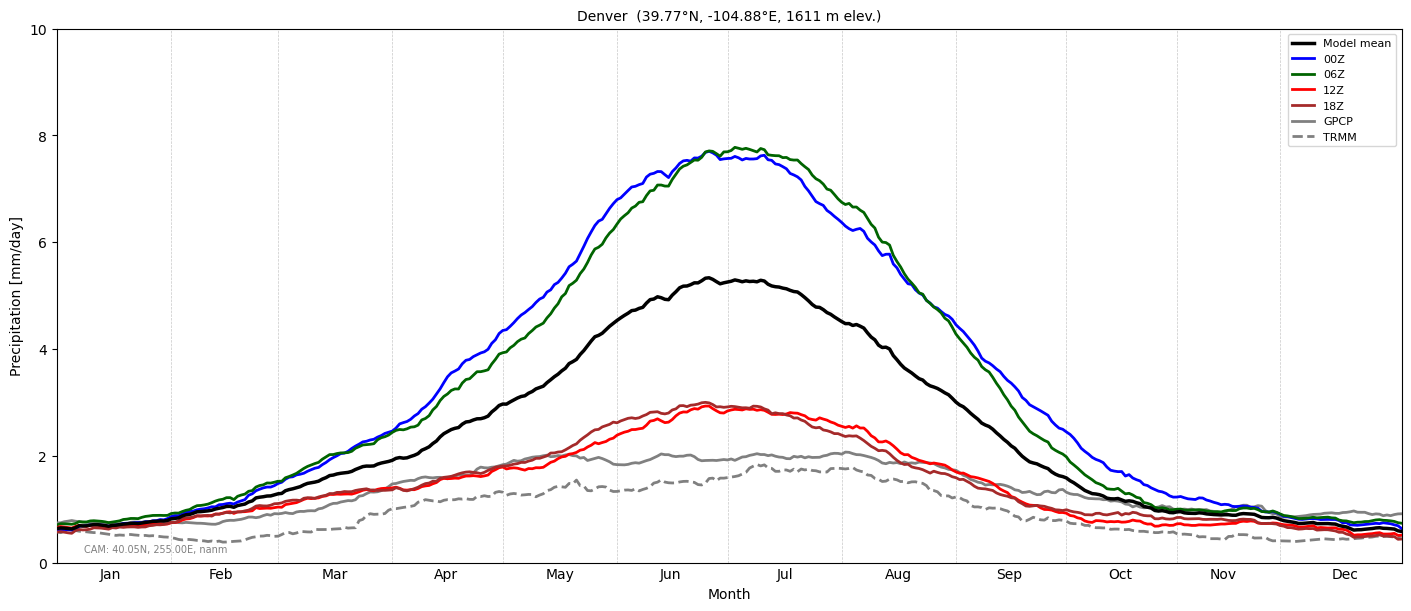

Saved: /glade/u/home/rneale/python/python-figs/raobs/Denver-PRECT_b.e11.B20TRC5CNBDRD.f09_g16.001_av_std_0012Z.png

--- 2D time-pressure plot ---

  CAM simulation: b.e11.B20TRC5CNBDRD.f09_g16.001
  Processed CAM file exists for U: /glade/work/rneale/large_ens/U/b.e11.B20TRC5CNBDRD.f09_g16.001.cam.h2.U.Denver.nc

*****************************************************************
  CAM: reading U
*****************************************************************
  Station location: 39.77 N, -104.88 E
  Reading from pre-processed file...
  Time range: 06Z 01 Jan 1990 to 00Z 01 Jan 2006


/glade/work/rneale/git/python-scripts/SONDE/raobs_utils.py:752: UserWarning: Requested year range 1990-2015 is outside available 1990-2006 in CAM file.
  warnings.warn(


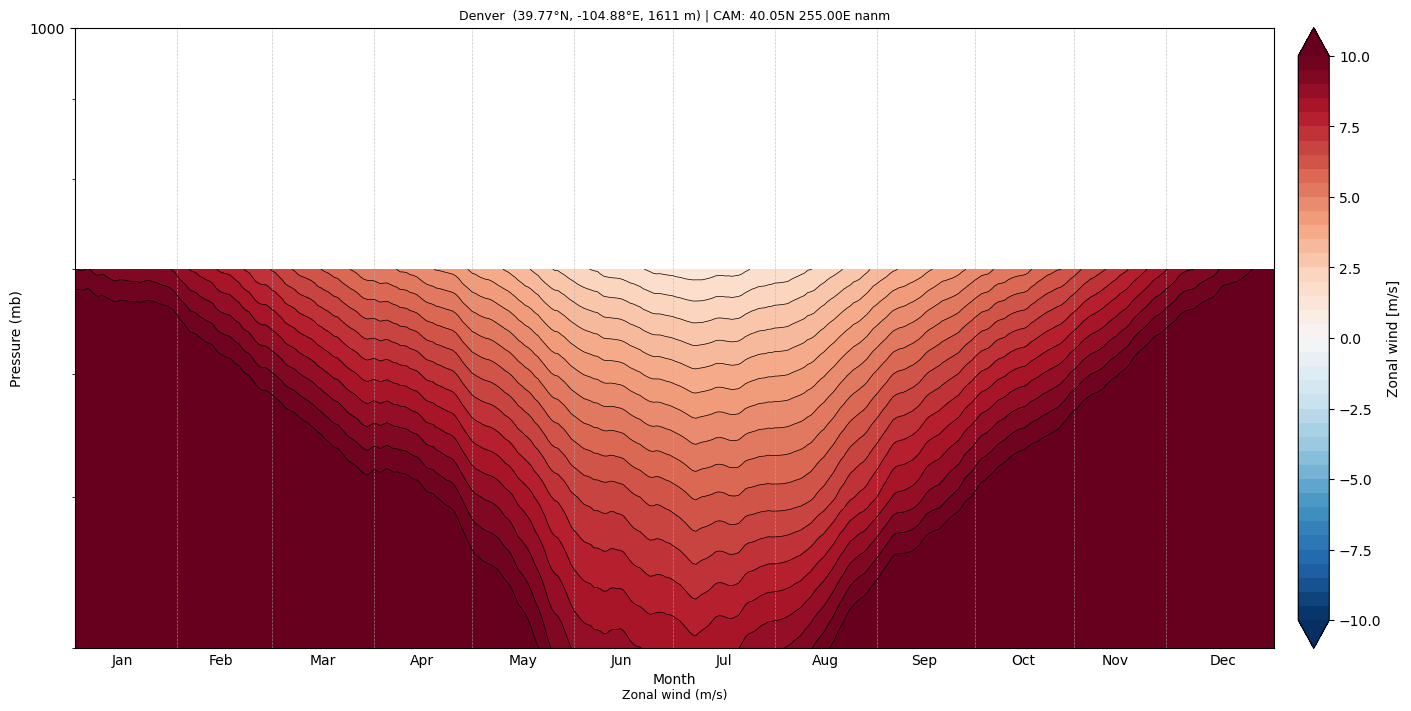

Saved: /glade/u/home/rneale/python/python-figs/raobs/Denver-U_b.e11.B20TRC5CNBDRD.f09_g16.001_av.png

Station Denver: DONE


In [3]:
for station in station_names:

    sdata = sdata_base.copy()
    sdata['station'] = station

    print(f"\n{'='*60}\n  Station: {station}\n{'='*60}")

    # Open RAOB file (decode_times=False because of non-standard units)
    rfile  = mypy.raob_file(station, dir_rdata)
    ds_r   = xr.open_dataset(rfile, decode_times=False)
    rtime  = mypy.get_raob_times(ds_r)
    mypy.raob_info(station, ds_r, rtime, sdata)

    # Decide model vs obs
    use_cam = 'crun_name' in vars() and crun_name is not None

    if use_cam:
        sdata['cam']  = True
        sdata['chan'] = 'h2' if crun_type == 'large_ens' else 'h1'
        dir_cdata = f'/glade/work/rneale/{crun_type}/' if crun_type == 'large_ens' else f'/glade/work/rneale/cam6_revert/'
        ps_suf = f'_{crun_name}'

        # 1D variable
        cfile_1d = mypy.cam_file(crun_name, dir_cdata, vplot1d, sdata)
        svar_1d  = mypy.cam_read(cfile_1d, vplot1d, sdata)
    else:
        sdata['cam'] = False
        ps_suf  = f'_{lev_type}levs'
        svar_1d = mypy.raob_read(ds_r, vplot1d, rtime, sdata)

    # Filename suffixes
    ps_suf1d = ps_suf + ('_av_std' if sdata['lp1d_av_std'] else '') + ('_0012Z' if sdata['lp1d_0012Z'] else '')
    ps_suf2d = ps_suf + ('_av' if sdata['lp2d_mean'] else '') + ('_nomean' if sdata['lp2d_nomean'] else '') + ('_std' if sdata['lp2d_std'] else '') + ('_0012Z_diff' if sdata['lp2d_0012Z'] else '')

    # ---- 1D plot ----
    if sdata['lp1d']:
        print('\n--- 1D plot ---')
        fig1, ax1 = plt.subplots(figsize=(14, 6), constrained_layout=True)

        if vplot1d == 'PRECT':
            # station_precip_plot overlays gridded obs (GPCP/TRMM) regardless of model;
            # when use_cam=False the model line is absent (da is NaN) but obs are shown.
            mypy.station_precip_plot(ax1, svar_1d, sdata)
        else:
            mypy.station_1d_plot(ax1, svar_1d, sdata)

        fname1 = os.path.join(dir_fig, f"{station}-{vplot1d}{ps_suf1d}.png")
        fig1.savefig(fname1, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {fname1}")
        plt.close(fig1)

    del svar_1d

    # ---- 2D time-pressure plot ----
    if sdata['lp2d']:
        print('\n--- 2D time-pressure plot ---')

        if use_cam:
            cfile_2d = mypy.cam_file(crun_name, dir_cdata, vplot2d, sdata)
            svar_2d  = mypy.cam_read(cfile_2d, vplot2d, sdata)
        else:
            svar_2d = mypy.raob_read(ds_r, vplot2d, rtime, sdata)

        if sdata['lp2d_0012Z']:
            # 3-panel figure: 00Z, 12Z, difference
            fig2, axes2 = plt.subplots(1, 3, figsize=(22, 7), constrained_layout=True)
            panels = mypy.station_tp_plot(axes2[0], svar_2d, sdata, fig=fig2)
        else:
            fig2, ax2 = plt.subplots(figsize=(14, 7), constrained_layout=True)
            mypy.station_tp_plot(ax2, svar_2d, sdata, fig=fig2)

        fname2 = os.path.join(dir_fig, f"{station}-{vplot2d}{ps_suf2d}.png")
        fig2.savefig(fname2, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {fname2}")
        plt.close(fig2)

        del svar_2d

    ds_r.close()
    print(f"\nStation {station}: DONE")